In [1]:

import kagglehub
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
Path to dataset files: /kaggle/input/tuberculosis-tb-chest-xray-dataset


In [2]:
import os

# Définir le chemin de base réel du jeu de données
base_dir = os.path.join(path, 'TB_Chest_Radiography_Database')

# Définir les classes réelles présentes dans le dataset
classes = ['Normal', 'Tuberculosis']

# Dictionnaire pour stocker le nombre d'images
image_counts = {}

# Compter les images pour chaque classe
for cls in classes:
    dir_path = os.path.join(base_dir, cls)
    if os.path.exists(dir_path):
        # Filtrer pour ne garder que les fichiers images (ex: .png)
        count = len([name for name in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, name)) and not name.startswith('.')])
        image_counts[cls] = count
    else:
        image_counts[cls] = 0

# Afficher le nombre d'images
print("Nombre d'images par classe dans le jeu de données :")
for cls, count in image_counts.items():
    print(f"  {cls}: {count} images")

Nombre d'images par classe dans le jeu de données :
  Normal: 3500 images
  Tuberculosis: 700 images


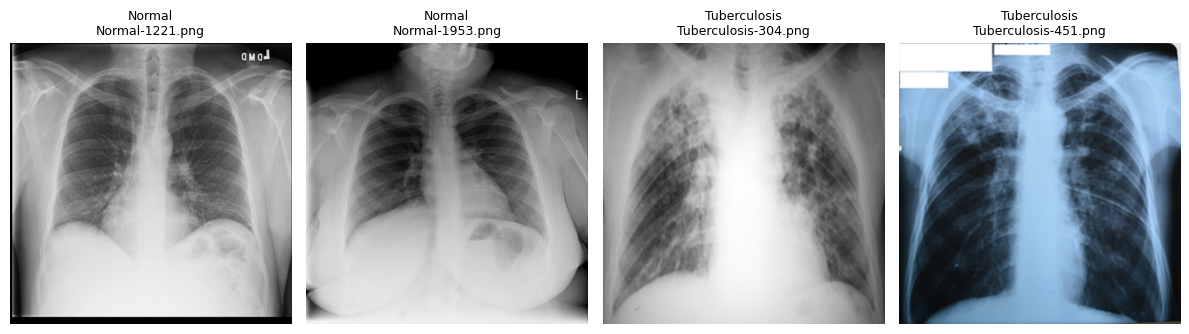

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Fonction mise à jour pour afficher des échantillons directement depuis les classes réelles
def display_sample_images(base_dir, classes, num_samples_per_class=2):
    plt.figure(figsize=(12, 6))
    plot_index = 1

    for cls in classes:
        dir_path = os.path.join(base_dir, cls)
        if os.path.exists(dir_path):
            # Récupérer tous les fichiers images
            images = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)) and not f.startswith('.')]

            if images:
                # Sélectionner aléatoirement des images
                sample_images = random.sample(images, min(len(images), num_samples_per_class))

                for img_name in sample_images:
                    img_path = os.path.join(dir_path, img_name)
                    img = mpimg.imread(img_path)

                    plt.subplot(1, len(classes) * num_samples_per_class, plot_index)
                    plt.imshow(img, cmap='gray')
                    plt.title(f'{cls}\n{img_name}', fontsize=9)
                    plt.axis('off')
                    plot_index += 1
            else:
                print(f"Aucune image trouvée dans {dir_path}")
        else:
            print(f"Dossier introuvable : {dir_path}")

    plt.tight_layout()
    plt.show()

# Afficher des exemples d'images pour chaque classe réelle
display_sample_images(base_dir, classes, num_samples_per_class=2)

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Définir les dimensions des images et la taille des lots
img_width, img_height = 150, 150
batch_size = 32

# 1. Lister toutes les images et leurs étiquettes
filepaths = []
labels = []

for cls in ['Normal', 'Tuberculosis']:
    dir_path = os.path.join(base_dir, cls)
    if os.path.exists(dir_path):
        for filename in os.listdir(dir_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepaths.append(os.path.join(dir_path, filename))
                labels.append(cls)

# Créer un DataFrame
df = pd.DataFrame({
    'filename': filepaths,
    'label': labels
})

# 2. Diviser en Train (70%), Val (15%), et Test (15%)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['label'])

print(f"Données d'entraînement : {len(train_df)}")
print(f"Données de validation : {len(val_df)}")
print(f"Données de test : {len(test_df)}")

Données d'entraînement : 2940
Données de validation : 630
Données de test : 630


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# Préparation des Générateurs de Données
# =========================

# Augmentation des données pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Uniquement redimensionnement (rescale) pour la validation et le test
test_datagen = ImageDataGenerator(rescale=1./255)

# Générateur d'entraînement
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

# Générateur de validation
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Générateur de test
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='label',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 2940 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.


In [6]:

from tensorflow.keras.applications import MobileNetV2 # You can choose other models like VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the pre-trained MobileNetV2 model, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze the layers of the base model to prevent them from being updated during training
# This preserves the learned features from ImageNet
base_model.trainable = False

# Create a new model on top of the pre-trained base
x = base_model.output
x = GlobalAveragePooling2D()(x) # Add a Global Average Pooling layer
x = Dense(128, activation='relu')(x) # Add a new dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Combine the base model and our new layers
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model with an appropriate learning rate
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

transfer_model.summary()

/tmp/ipykernel_9051/3849439317.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
import numpy as np
# 3. Define Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
# Train with the callback
epochs = 15

history = transfer_model.fit(
    train_generator,

    steps_per_epoch=int(
        np.ceil(
            train_generator.samples /
            train_generator.batch_size
        )
    ),

    epochs=epochs,

    validation_data=validation_generator,

    validation_steps=int(
        np.ceil(
            validation_generator.samples /
            validation_generator.batch_size
        )
    ),

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8636 - loss: 0.3409 - val_accuracy: 0.9175 - val_loss: 0.2007 - learning_rate: 1.0000e-04
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9187 - loss: 0.2214 - val_accuracy: 0.9413 - val_loss: 0.1367 - learning_rate: 1.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9381 - loss: 0.1710 - val_accuracy: 0.9444 - val_loss: 0.1223 - learning_rate: 1.0000e-04
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9452 - loss: 0.1386 - val_accuracy: 0.9492 - val_loss: 0.1108 - learning_rate: 1.0000e-04
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9541 - loss: 0.1351 - val_accuracy: 0.9429 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9582 - loss: 0.1167 - val_accuracy: 0.9429 - val_loss: 0.1238 - learning_rate: 1.0000e-04
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9598 - 

In [8]:
loss, accuracy = transfer_model.evaluate(
    validation_generator
)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 807ms/step - accuracy: 0.9524 - loss: 0.0975
Validation Loss: 0.09748684614896774
Validation Accuracy: 0.9523809552192688


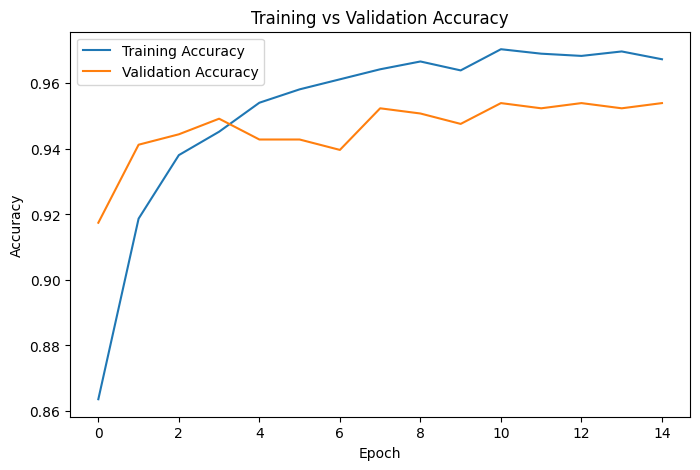

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()


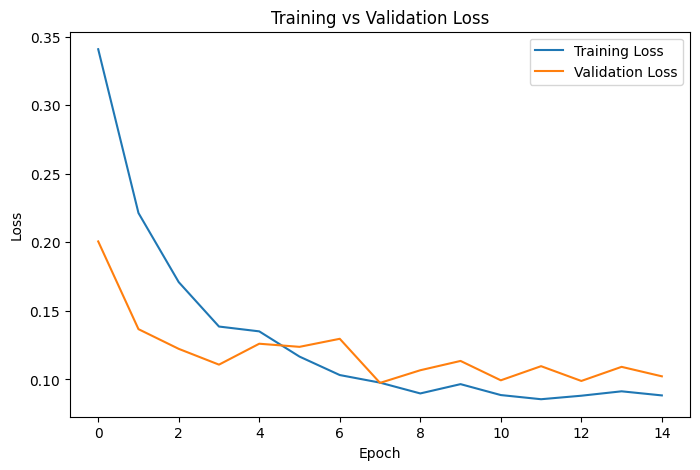

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()

In [11]:

transfer_model.save('improved_cnn_model.h5')

print("Model saved successfully!")

Model saved successfully!


20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 893ms/step - accuracy: 0.9492 - loss: 0.1097
Test Loss: 0.1097
Test Accuracy: 0.9492
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 956ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97       525
Tuberculosis       0.99      0.70      0.82       105

    accuracy                           0.95       630
   macro avg       0.97      0.85      0.90       630
weighted avg       0.95      0.95      0.95       630



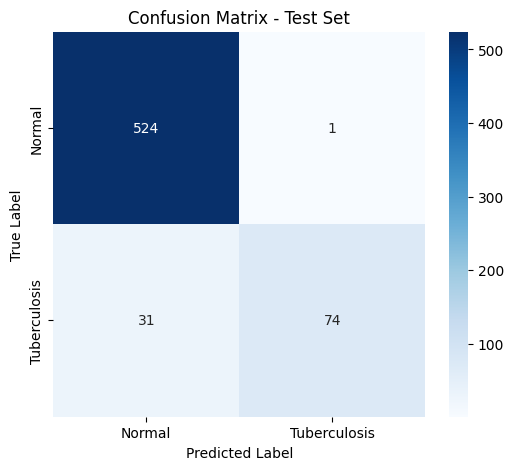

In [12]:

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test set
test_loss, test_accuracy = transfer_model.evaluate(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict probabilities
test_generator.reset()
predictions = transfer_model.predict(test_generator, steps=int(np.ceil(test_generator.samples / test_generator.batch_size)))

# Convert probabilities to binary class predictions (0 or 1)
y_pred = (predictions > 0.5).astype(int).flatten()

# Get true labels
y_true = test_generator.classes

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_generator.class_indices.keys()), yticklabels=list(test_generator.class_indices.keys()))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [13]:

!pip install -q gradio

In [14]:

import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_pneumonia(img):
    # Re-verify and resize the image to match model input
    img = img.resize((img_width, img_height))
    img_array = image.img_to_array(img)

    # Normalize the pixel values
    img_array = img_array / 255.0

    # Expand dimensions to fit (1, 150, 150, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Perform prediction
    prediction = transfer_model.predict(img_array)[0][0]

    # Format output labels and confidence score
    if prediction > 0.5:
        confidence = prediction * 100
        label = "TUBERCULOSIS "
        color = "red"
    else:
        confidence = (1 - prediction) * 100
        label = "NORMAL "
        color = "green"

    return f"Expected announcement: {label}\nConfidence level: {confidence:.2f}%"

# Create Custom Gradio Interface
interface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil", label="(Upload Chest X-Ray)"),
    outputs=gr.Textbox(label="(Prediction Output)"),
    title="Smart Tubercolosis Detection System 🫁",
    description="Upload a chest X-ray and the trained AI model will analyse it immediately to determine whether it is normal or shows signs of tuberculosis.",
    theme="soft"
)

# Launch Interface with a shareable public link
interface.launch(share=True, debug=True)


/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8a6386f2cc41386d76.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8a6386f2cc41386d76.gradio.live
